In [2]:
!pip install pymysql pandas matplotlib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import plotly.express as px

conn = pymysql.connect(
    host="35.199.115.174",
    user="looqbox-challenge",
    password="looq-challenge",
    database="looqbox-challenge",
    port=3306
)

print("Conexão realizada com sucesso!")

Conexão realizada com sucesso!


In [38]:
def retrieve_data(product_code=None, store_code=None, date=None):
    """
    Recupera dados da tabela data_product_sales.

    Parameters
    ----------
    product_code : int
        Código do produto.

    store_code : int
        Código da loja.

    date : str ou list
        Data única:
        '2019-01-01'

        ou intervalo:
        ['2019-01-01', '2019-01-31']

    Returns
    -------
    pandas.DataFrame
    """

    query = """
    SELECT
        STORE_CODE,
        PRODUCT_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
    FROM data_product_sales
    WHERE 1=1
    """

    if product_code is not None:
        query += f" AND PRODUCT_CODE = {product_code}"

    if store_code is not None:
        query += f" AND STORE_CODE = {store_code}"

    if date is not None:

        if isinstance(date, list) and len(date) == 2:
            query += f" AND DATE BETWEEN '{date[0]}' AND '{date[1]}'"

        elif isinstance(date, str):
            query += f" AND DATE = '{date}'"

    print("SQL gerado:")
    print(query)

    df = pd.read_sql(query, conn)

    return df

In [39]:
my_data = retrieve_data(
    product_code=18,
    store_code=1,
    date=['2019-01-01', '2019-01-31']
)

my_data.head()

SQL gerado:

    SELECT
        STORE_CODE,
        PRODUCT_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
    FROM data_product_sales
    WHERE 1=1
     AND PRODUCT_CODE = 18 AND STORE_CODE = 1 AND DATE BETWEEN '2019-01-01' AND '2019-01-31'


/tmp/ipykernel_589/2462962621.py:53: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.5,65.0
1,1,18,2019-01-02,1297.1,119.0
2,1,18,2019-01-03,1144.5,105.0
3,1,18,2019-01-04,1090.0,100.0
4,1,18,2019-01-05,893.8,82.0


In [40]:
query = """
SELECT
    Genre,
    Rating
FROM IMDB_movies
"""

df_imdb = pd.read_sql(query, conn)

df_imdb.head()

/tmp/ipykernel_589/1292519553.py:8: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,Genre,Rating
0,"Action,Adventure,Sci-Fi",8.0
1,"Adventure,Mystery,Sci-Fi",7.0
2,"Horror,Thriller",7.0
3,"Animation,Comedy,Family",7.0
4,"Action,Adventure,Fantasy",6.0


In [41]:
top_genres = (
    df_imdb.groupby("Genre")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_genres

,Rating
Genre,
"Animation,Drama,Fantasy",9.0
"Drama,Family,Music",9.0
"Adventure,Drama,Sci-Fi",8.5
"Action,Fantasy,War",8.0
"Action,Drama,War",8.0
"Adventure,Comedy,Horror",8.0
"Adventure,Drama,Western",8.0
"Action,Drama,Horror",8.0
"Animation,Fantasy",8.0


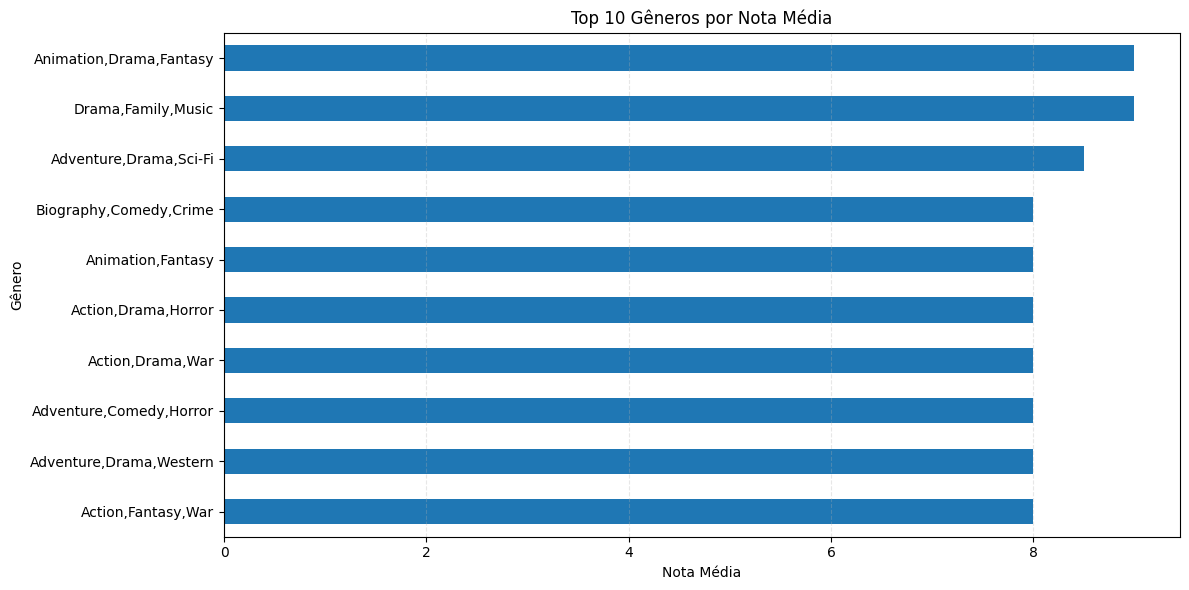

In [42]:
plt.figure(figsize=(12,6))

top_genres.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Gêneros por Nota Média")
plt.xlabel("Nota Média")
plt.ylabel("Gênero")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [43]:
query = """
SELECT
    Director,
    Rating
FROM IMDB_movies
"""

df_director = pd.read_sql(query, conn)

top_directors = (
    df_director.groupby("Director")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_directors

/tmp/ipykernel_589/1611869750.py:8: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,Rating
Director,
Aamir Khan,9.0
Christopher Nolan,9.0
Nitesh Tiwari,9.0
Florian Henckel von Donnersmarck,9.0
Olivier Nakache,9.0
Makoto Shinkai,9.0
Damien Chazelle,8.5
Aisling Walsh,8.0
Anthony Russo,8.0


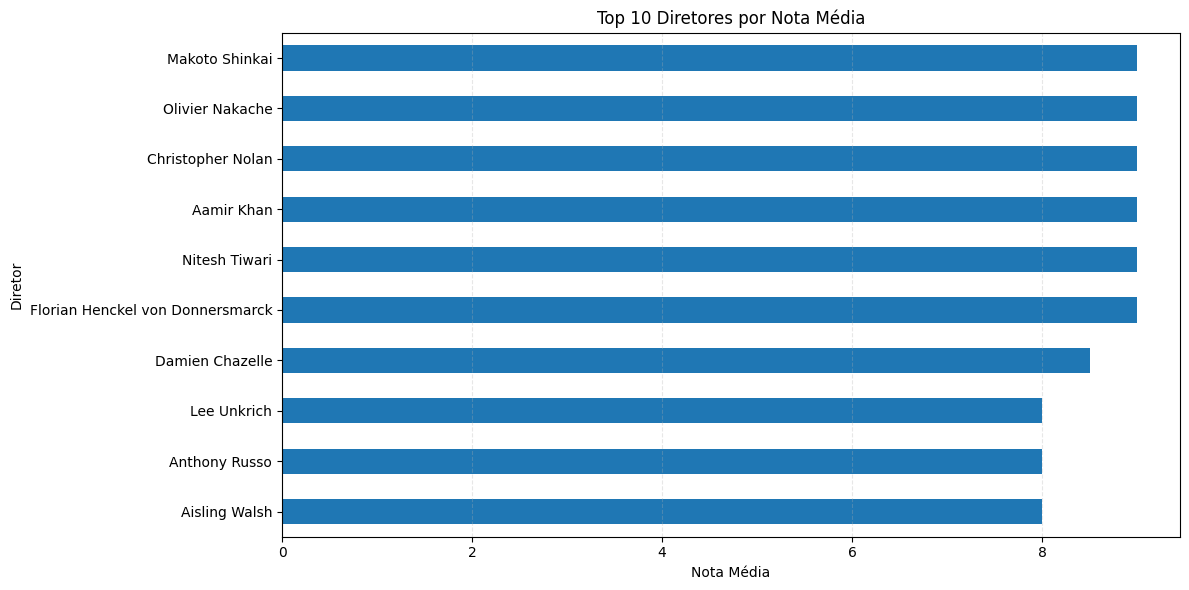

In [44]:
plt.figure(figsize=(12,6))

top_directors.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Diretores por Nota Média")
plt.xlabel("Nota Média")
plt.ylabel("Diretor")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [4]:
query_store = """
SELECT
    STORE_CODE,
    STORE_NAME,
    START_DATE,
    END_DATE,
    BUSINESS_NAME,
    BUSINESS_CODE
FROM data_store_cad
"""

query_sales = """
SELECT
    STORE_CODE,
    DATE,
    SALES_VALUE,
    SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

df_store = pd.read_sql(query_store, conn)
df_sales = pd.read_sql(query_sales, conn)

/tmp/ipykernel_589/22385293.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_store = pd.read_sql(query_store, conn)
/tmp/ipykernel_589/22385293.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales = pd.read_sql(query_sales, conn)


In [6]:
df_sales["DATE"] = pd.to_datetime(df_sales["DATE"])

df_sales_filtered = df_sales[
    (df_sales["DATE"] >= "2019-10-01") &
    (df_sales["DATE"] <= "2019-12-31")
]

In [7]:
df_case2 = df_sales_filtered.merge(
    df_store,
    on="STORE_CODE",
    how="left"
)

In [8]:
tm_by_store = (
    df_case2
    .groupby(["STORE_NAME", "BUSINESS_NAME"], as_index=False)
    .agg({
        "SALES_VALUE": "sum",
        "SALES_QTY": "sum"
    })
)

tm_by_store["TM"] = tm_by_store["SALES_VALUE"] / tm_by_store["SALES_QTY"]

tm_by_store = tm_by_store.rename(columns={
    "STORE_NAME": "Loja",
    "BUSINESS_NAME": "Categoria"
})

tm_by_store = tm_by_store.sort_values("TM", ascending=False)

tm_by_store[["Loja", "Categoria", "TM"]]

,Loja,Categoria,TM
13,Rio de Janeiro,Farma,29.588389
9,Madri,Farma,29.030712
8,London,Farma,28.991493
7,Hong Kong,Farma,26.351368
5,Chicago,Varejo,15.525953
12,Paris,Proximidade,15.388798
3,Berlin,Proximidade,15.388798
0,Bahia,Atacado,15.388798
16,Sao Paulo,Varejo,15.388798
6,Dubai,Atacado,15.388798


In [11]:
!pip install pandas matplotlib numpy

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [13]:
tm_data = pd.DataFrame({
    "Loja": [
        "Bahia", "Bangkok", "Belém", "Berlim", "Buenos Aires",
        "Chicago", "Dubai", "Hong Kong", "Londres", "Madri",
        "Miami", "Nova Iorque", "Paris", "Rio de Janeiro", "Roma",
        "Salvador", "São Paulo", "Sidney", "Tóquio", "Vancouver"
    ],
    "Categoria": [
        "Atacadinho", "Posto", "Proximidade", "Proximidade", "Atacadinho",
        "Varejo", "Atacadinho", "Farma", "Farma", "Farma",
        "Posto", "Proximidade", "Proximidade", "Farma", "Varejo",
        "Atacadinho", "Varejo", "Posto", "Varejo", "Posto"
    ],
    "TM": [
        15.39, 13.67, 15.37, 15.39, 15.39,
        15.53, 15.39, 26.35, 28.99, 29.03,
        13.67, 15.39, 15.39, 29.59, 15.39,
        15.39, 15.39, 13.67, 15.39, 13.67
    ]
})

tm_data.head()

,Loja,Categoria,TM
0,Bahia,Atacadinho,15.39
1,Bangkok,Posto,13.67
2,Belém,Proximidade,15.37
3,Berlim,Proximidade,15.39
4,Buenos Aires,Atacadinho,15.39


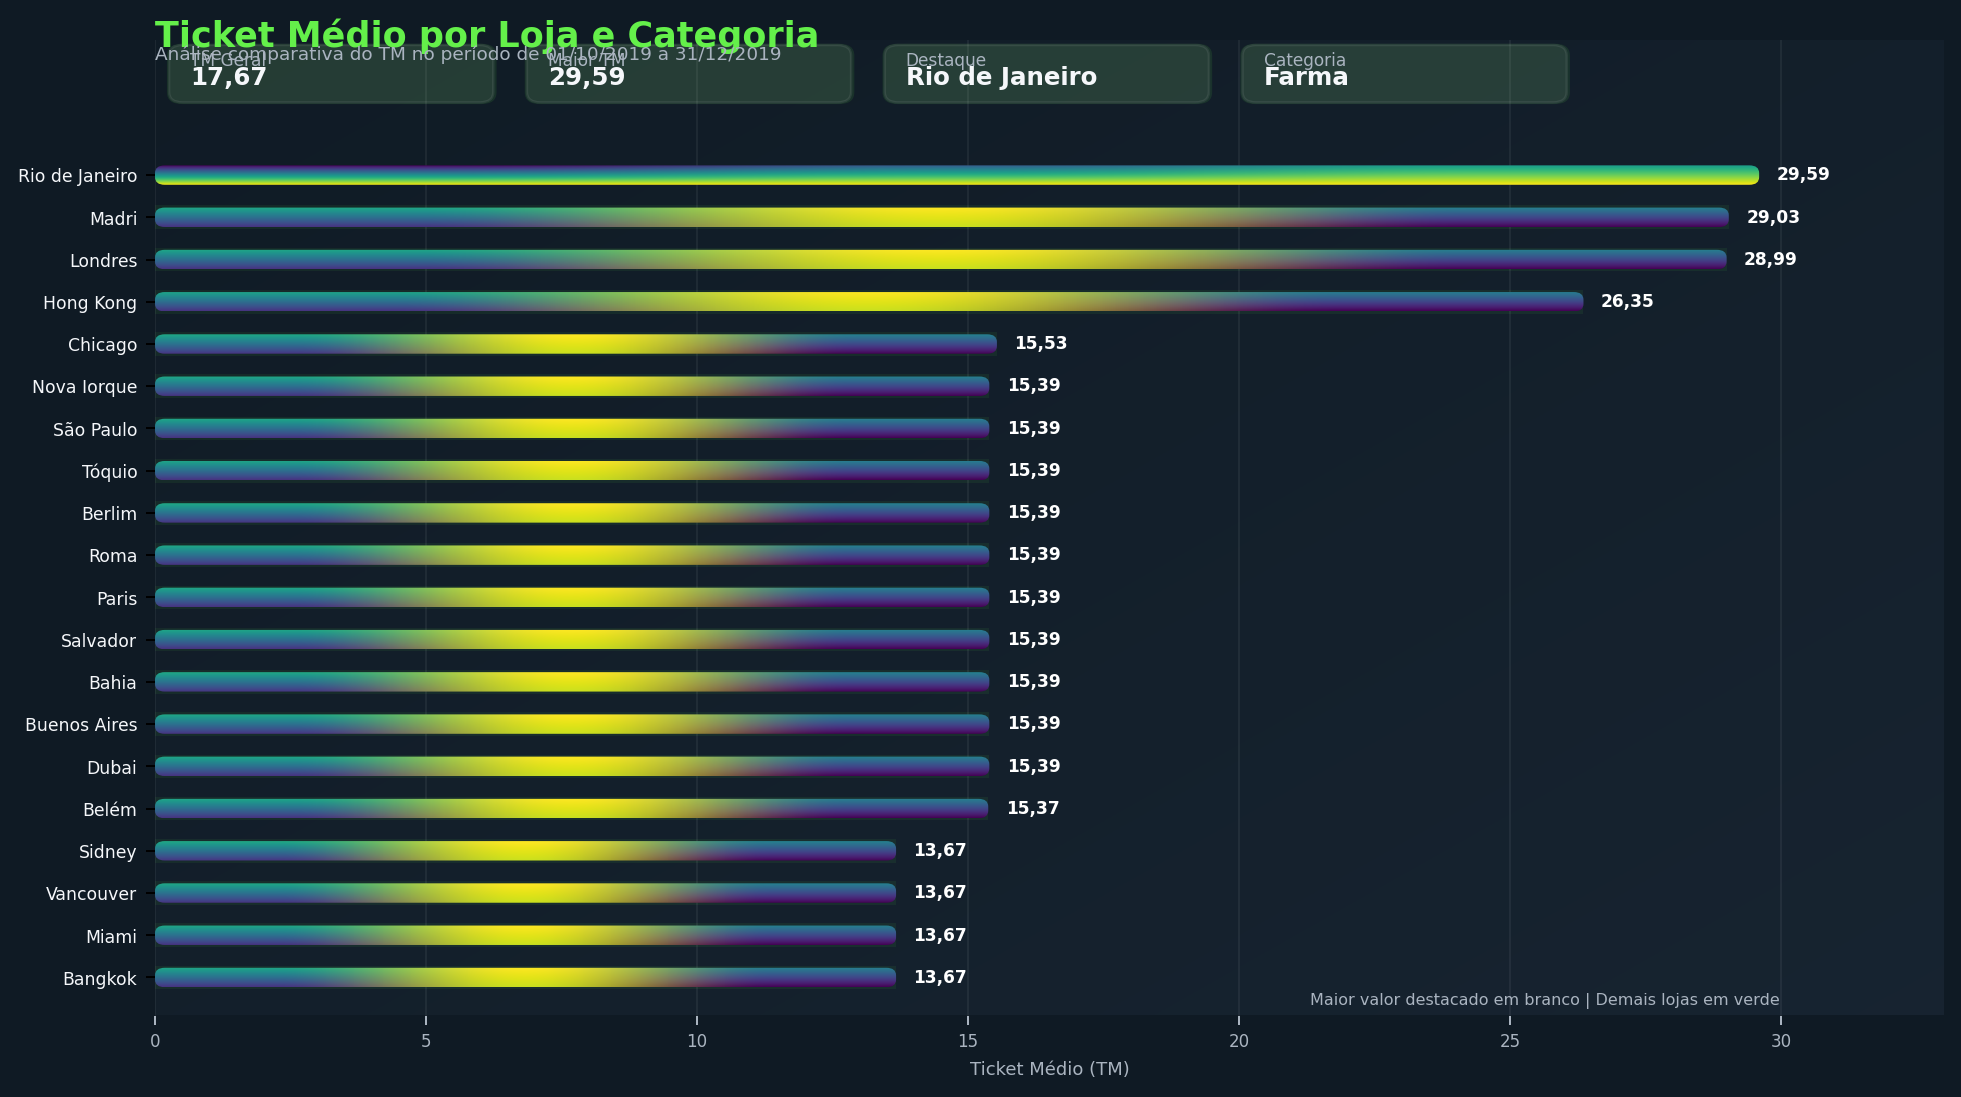

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

tm_data = pd.DataFrame({
    "Loja": [
        "Bahia", "Bangkok", "Belém", "Berlim", "Buenos Aires",
        "Chicago", "Dubai", "Hong Kong", "Londres", "Madri",
        "Miami", "Nova Iorque", "Paris", "Rio de Janeiro", "Roma",
        "Salvador", "São Paulo", "Sidney", "Tóquio", "Vancouver"
    ],
    "Categoria": [
        "Atacadinho", "Posto", "Proximidade", "Proximidade", "Atacadinho",
        "Varejo", "Atacadinho", "Farma", "Farma", "Farma",
        "Posto", "Proximidade", "Proximidade", "Farma", "Varejo",
        "Atacadinho", "Varejo", "Posto", "Varejo", "Posto"
    ],
    "TM": [
        15.39, 13.67, 15.37, 15.39, 15.39,
        15.53, 15.39, 26.35, 28.99, 29.03,
        13.67, 15.39, 15.39, 29.59, 15.39,
        15.39, 15.39, 13.67, 15.39, 13.67
    ]
})

df = tm_data.sort_values("TM", ascending=True).reset_index(drop=True)

def hex_to_rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)]) / 255

def rounded_gradient_barh(ax, y, width, height, color_start, color_end, x_start=0, radius=0.18, zorder=3):
    grad = np.linspace(0, 1, 256).reshape(256, 1)
    c1 = hex_to_rgb(color_start)
    c2 = hex_to_rgb(color_end)
    img = c1 * (1 - grad) + c2 * grad

    patch = FancyBboxPatch(
        (x_start, y - height / 2),
        width,
        height,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        linewidth=0,
        facecolor="none"
    )

    ax.add_patch(patch)

    im = ax.imshow(
        img,
        extent=[x_start, x_start + width, y - height / 2, y + height / 2],
        aspect="auto",
        origin="lower",
        zorder=zorder
    )

    im.set_clip_path(patch)

fig, ax = plt.subplots(figsize=(11, 6.2), dpi=180)

fig.patch.set_facecolor("#0F1A24")
ax.set_facecolor("#0F1A24")

# Fundo gradiente
w, h = 1600, 900
x = np.linspace(0, 1, w)
y = np.linspace(0, 1, h)
X, Y = np.meshgrid(x, y)
diag = (X + Y) / 2

bg_start = hex_to_rgb("#0F1A24")
bg_end = hex_to_rgb("#182532")
bg = bg_start * (1 - diag[..., None]) + bg_end * diag[..., None]

ax.imshow(
    bg,
    extent=[-4, 36, -4, len(df) + 5],
    aspect="auto",
    zorder=0
)

# KPIs
tm_geral = df["TM"].mean()
melhor_loja = df.loc[df["TM"].idxmax(), "Loja"]
melhor_tm = df["TM"].max()
melhor_categoria = df.loc[df["TM"].idxmax(), "Categoria"]

kpis = [
    ("TM Geral", f"{tm_geral:.2f}".replace(".", ",")),
    ("Maior TM", f"{melhor_tm:.2f}".replace(".", ",")),
    ("Destaque", melhor_loja),
    ("Categoria", melhor_categoria)
]

card_x = [0.4, 7.0, 13.6, 20.2]

for x0, (title, value) in zip(card_x, kpis):
    glow = FancyBboxPatch(
        (x0 - 0.04, len(df) + 0.82),
        5.8,
        1.15,
        boxstyle="round,pad=0.14,rounding_size=0.28",
        linewidth=0,
        facecolor="#64F04A",
        alpha=0.10,
        zorder=1
    )
    ax.add_patch(glow)

    card = FancyBboxPatch(
        (x0, len(df) + 0.86),
        5.7,
        1.08,
        boxstyle="round,pad=0.14,rounding_size=0.25",
        linewidth=1,
        edgecolor=(1, 1, 1, 0.08),
        facecolor=(1, 1, 1, 0.06),
        zorder=2
    )
    ax.add_patch(card)

    ax.text(
        x0 + 0.25,
        len(df) + 1.6,
        title,
        color="#AAB4C0",
        fontsize=6.8,
        zorder=3
    )

    ax.text(
        x0 + 0.25,
        len(df) + 1.15,
        value,
        color="#F5F7FA",
        fontsize=9.8,
        fontweight="bold",
        zorder=3
    )

# Barras
bar_height = 0.46
max_value = df["TM"].max()

for i, row in df.iterrows():
    is_max = row["TM"] == max_value

    if is_max:
        c1, c2 = "#FFFFFF", "#DCE6EF"
    else:
        c1, c2 = "#64F04A", "#B8FF9A"

    if not is_max:
        ax.barh(
            i,
            row["TM"],
            height=bar_height + 0.10,
            color="#64F04A",
            alpha=0.07,
            zorder=1
        )

    rounded_gradient_barh(
        ax=ax,
        y=i,
        width=row["TM"],
        height=bar_height,
        color_start=c1,
        color_end=c2,
        radius=0.18,
        zorder=3
    )

    ax.text(
        row["TM"] + 0.32,
        i,
        f"{row['TM']:.2f}".replace(".", ","),
        va="center",
        ha="left",
        fontsize=6.8,
        fontweight="bold",
        color="#FFFFFF",
        zorder=5
    )

# Eixos
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Loja"], color="#F5F7FA", fontsize=6.9)

ax.set_xlim(0, 33)
ax.set_ylim(-0.9, len(df) + 2.2)

ax.tick_params(axis="x", colors="#AAB4C0", labelsize=6.7)
ax.grid(axis="x", color="#FFFFFF", alpha=0.08, linewidth=0.6)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Ticket Médio (TM)", color="#AAB4C0", fontsize=7.2)
ax.set_ylabel("")

# Título e subtítulo
ax.text(
    0,
    len(df) + 2.05,
    "Ticket Médio por Loja e Categoria",
    color="#64F04A",
    fontsize=14,
    fontweight="bold",
    zorder=5
)

ax.text(
    0,
    len(df) + 1.72,
    "Análise comparativa do TM no período de 01/10/2019 a 31/12/2019",
    color="#AAB4C0",
    fontsize=7.4,
    zorder=5
)

ax.text(
    21.3,
    -0.65,
    "Maior valor destacado em branco | Demais lojas em verde",
    color="#AAB4C0",
    fontsize=6.4,
    zorder=5
)

plt.tight_layout()

plt.savefig(
    "ticket_medio_dashboard_looqbox_style_pdf.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="#0F1A24"
)

plt.show()

In [18]:
!pip install plotly kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.0 MB/s eta 0:00:00


In [33]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass

In [34]:
query_imdb = """
SELECT
    Title,
    Genre,
    Director,
    Year,
    Runtime,
    Rating,
    Votes,
    RevenueMillions,
    Metascore
FROM IMDB_movies
WHERE RevenueMillions IS NOT NULL
"""

df_imdb = pd.read_sql(query_imdb, conn)

df_imdb.head()

/tmp/ipykernel_589/3038890183.py:16: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,Title,Genre,Director,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,2014,121,8.0,757074,333.0,76.0
1,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,2012,124,7.0,485820,126.0,65.0
2,Split,"Horror,Thriller",M. Night Shyamalan,2016,117,7.0,157606,138.0,62.0
3,Sing,"Animation,Comedy,Family",Christophe Lourdelet,2016,108,7.0,60545,270.0,59.0
4,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,2016,123,6.0,393727,325.0,40.0


In [35]:
df_imdb["Rating"] = pd.to_numeric(df_imdb["Rating"], errors="coerce")
df_imdb["RevenueMillions"] = pd.to_numeric(df_imdb["RevenueMillions"], errors="coerce")
df_imdb["Votes"] = pd.to_numeric(df_imdb["Votes"], errors="coerce")
df_imdb["Year"] = pd.to_numeric(df_imdb["Year"], errors="coerce")
df_imdb["Metascore"] = pd.to_numeric(df_imdb["Metascore"], errors="coerce")

df_imdb = df_imdb.dropna(
    subset=["Title", "Genre", "Rating", "RevenueMillions", "Votes"]
)

df_imdb = df_imdb[df_imdb["RevenueMillions"] > 0]

df_imdb["Main_Genre"] = df_imdb["Genre"].str.split(",").str[0]

df_imdb.head()

,Title,Genre,Director,Year,Runtime,Rating,Votes,RevenueMillions,Metascore,Main_Genre
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,2014,121,8.0,757074,333.0,76.0,Action
1,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,2012,124,7.0,485820,126.0,65.0,Adventure
2,Split,"Horror,Thriller",M. Night Shyamalan,2016,117,7.0,157606,138.0,62.0,Horror
3,Sing,"Animation,Comedy,Family",Christophe Lourdelet,2016,108,7.0,60545,270.0,59.0,Animation
4,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,2016,123,6.0,393727,325.0,40.0,Action


In [36]:
def create_imdb_dashboard(search_text="", selected_genre="Todos"):
    df_plot = df_imdb.copy()

    if selected_genre != "Todos":
        df_plot = df_plot[df_plot["Main_Genre"] == selected_genre]

    df_plot = df_plot.sort_values("RevenueMillions", ascending=False).head(300)

    avg_rating = df_plot["Rating"].mean()
    avg_revenue = df_plot["RevenueMillions"].mean()

    min_votes = df_plot["Votes"].min()
    max_votes = df_plot["Votes"].max()

    if max_votes == min_votes:
        sizes = np.repeat(18, len(df_plot))
    else:
        sizes = 8 + ((df_plot["Votes"] - min_votes) / (max_votes - min_votes)) * 32

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df_plot["Rating"],
            y=df_plot["RevenueMillions"],
            mode="markers",
            marker=dict(
                size=sizes,
                color=df_plot["RevenueMillions"],
                colorscale=[
                    [0, "#1B4332"],
                    [0.35, "#64F04A"],
                    [1, "#B8FF9A"]
                ],
                opacity=0.72,
                line=dict(
                    width=1,
                    color="#B8FF9A"
                ),
                colorbar=dict(
                    title="Receita",
                    tickfont=dict(color="#AAB4C0"),
                    titlefont=dict(color="#AAB4C0")
                )
            ),
            customdata=np.stack(
                [
                    df_plot["Title"],
                    df_plot["Director"],
                    df_plot["Year"],
                    df_plot["Main_Genre"],
                    df_plot["Votes"],
                    df_plot["Metascore"]
                ],
                axis=-1
            ),
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                "Diretor: %{customdata[1]}<br>"
                "Ano: %{customdata[2]}<br>"
                "Gênero: %{customdata[3]}<br>"
                "Nota IMDb: %{x}<br>"
                "Receita: US$ %{y:.2f} mi<br>"
                "Votos: %{customdata[4]}<br>"
                "Metascore: %{customdata[5]}<extra></extra>"
            ),
            name="Filmes"
        )
    )

    if search_text.strip():
        df_search = df_plot[
            df_plot["Title"].str.contains(search_text, case=False, na=False)
        ]

        if len(df_search) > 0:
            fig.add_trace(
                go.Scatter(
                    x=df_search["Rating"],
                    y=df_search["RevenueMillions"],
                    mode="markers+text",
                    marker=dict(
                        size=24,
                        color="#FFFFFF",
                        line=dict(
                            width=3,
                            color="#64F04A"
                        ),
                        symbol="star"
                    ),
                    text=df_search["Title"],
                    textposition="top center",
                    textfont=dict(
                        color="#FFFFFF",
                        size=11
                    ),
                    name="Filme buscado",
                    hovertemplate=(
                        "<b>%{text}</b><br>"
                        "Nota IMDb: %{x}<br>"
                        "Receita: US$ %{y:.2f} mi<extra></extra>"
                    )
                )
            )

    fig.add_vline(
        x=avg_rating,
        line_width=1,
        line_dash="dash",
        line_color="rgba(255,255,255,0.25)"
    )

    fig.add_hline(
        y=avg_revenue,
        line_width=1,
        line_dash="dash",
        line_color="rgba(255,255,255,0.25)"
    )

    fig.add_annotation(
        x=avg_rating,
        y=df_plot["RevenueMillions"].max(),
        text=f"Nota média: {avg_rating:.2f}",
        showarrow=False,
        font=dict(color="#AAB4C0", size=11),
        xanchor="left"
    )

    fig.add_annotation(
        x=df_plot["Rating"].max(),
        y=avg_revenue,
        text=f"Receita média: US$ {avg_revenue:.1f} mi",
        showarrow=False,
        font=dict(color="#AAB4C0", size=11),
        yanchor="bottom"
    )

    fig.update_layout(
        template="plotly_dark",
        width=1150,
        height=720,
        paper_bgcolor="#0F1A24",
        plot_bgcolor="#111F2A",
        title=dict(
            text="IMDb Movies | Receita, Nota e Popularidade",
            x=0.5,
            font=dict(
                size=26,
                color="#64F04A"
            )
        ),
        font=dict(
            family="Arial",
            color="#F5F7FA"
        ),
        xaxis=dict(
            title="Nota IMDb",
            gridcolor="rgba(255,255,255,0.08)",
            zeroline=False
        ),
        yaxis=dict(
            title="Receita em Milhões de Dólares",
            gridcolor="rgba(255,255,255,0.08)",
            zeroline=False
        ),
        legend=dict(
            title="Legenda",
            bgcolor="rgba(15,26,36,0.6)",
            bordercolor="rgba(255,255,255,0.08)",
            borderwidth=1
        ),
        margin=dict(l=80, r=50, t=100, b=70)
    )

    fig.add_annotation(
        text="Cada bolha representa um filme | Tamanho = votos | Cor = receita | Estrela branca = filme buscado",
        xref="paper",
        yref="paper",
        x=0,
        y=1.08,
        showarrow=False,
        font=dict(
            size=12,
            color="#AAB4C0"
        )
    )

    return fig

In [37]:
genre_options = ["Todos"] + sorted(df_imdb["Main_Genre"].dropna().unique().tolist())

search_box = widgets.Text(
    value="",
    placeholder="Digite parte do nome do filme...",
    description="Buscar:",
    layout=widgets.Layout(width="45%")
)

genre_dropdown = widgets.Dropdown(
    options=genre_options,
    value="Todos",
    description="Gênero:",
    layout=widgets.Layout(width="35%")
)

ui = widgets.HBox([search_box, genre_dropdown])

out = widgets.interactive_output(
    lambda busca, genero: create_imdb_dashboard(busca, genero).show(),
    {
        "busca": search_box,
        "genero": genre_dropdown
    }
)

display(ui, out)

Output()